In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

from utilities import *

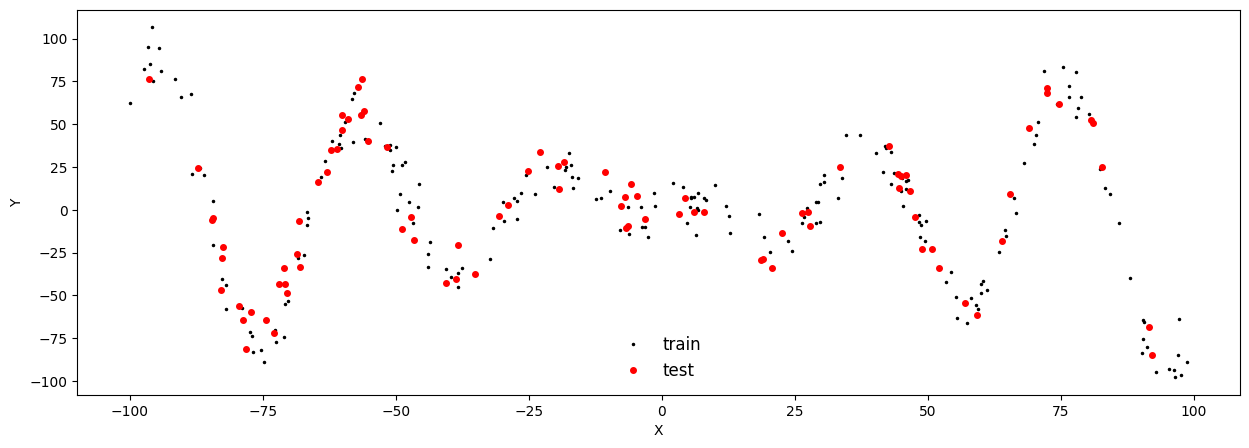

In [7]:
sample_size = 300
variance = 10
scale = 100
period = 6


x_train, y_train = data_simulation(int(0.7*sample_size), scale, period, variance)
x_test, y_test = data_simulation(int(0.3*sample_size), scale, period, variance)

# The scatter_plot function is in the utilities script
plt = scatter_plot(x_train, x_test, y_train, y_test)  

Polynomial degree:  0  | MSE train: 1884.1107  | MSE test: 1527.087
Polynomial degree:  1  | MSE train: 1784.4669  | MSE test: 1712.433
Polynomial degree:  3  | MSE train: 1564.5959  | MSE test: 1782.6154
Polynomial degree:  5  | MSE train: 1172.5726  | MSE test: 1255.5889
Polynomial degree:  10  | MSE train: 854.9282  | MSE test: 992.5196
Polynomial degree:  20  | MSE train: 73.221  | MSE test: 110.5787
Polynomial degree:  50  | MSE train: 66.9016  | MSE test: 130.3896


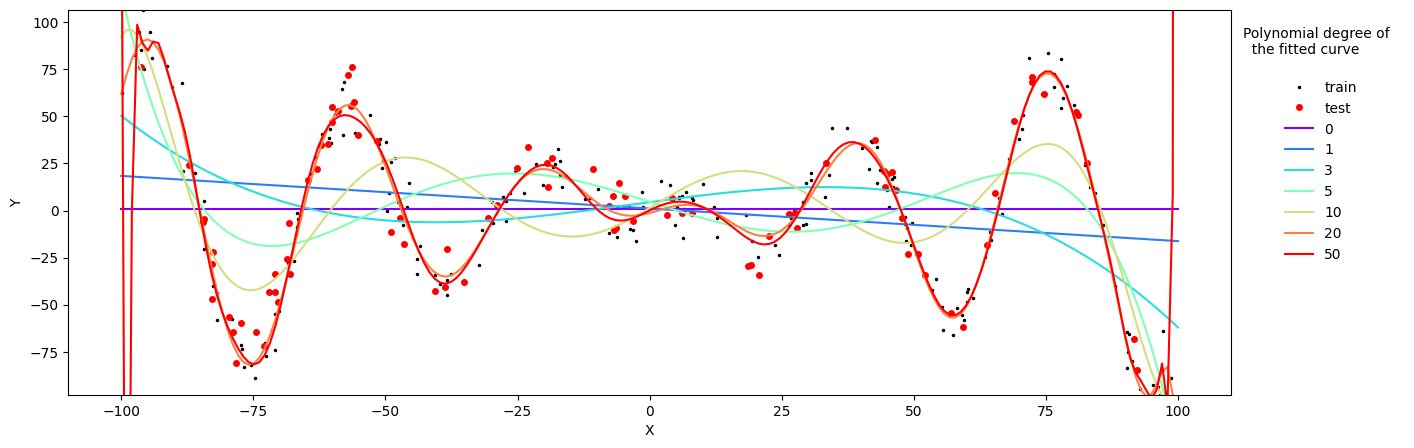

In [8]:
degree = [0, 1, 3, 5, 10, 20, 50]   
plot_polynomial_curves(x_train, x_test, y_train, y_test, degree, scale)

In [16]:
def simu_data(sample_size, w0, w1):
    x = np.random.uniform(0, 1, sample_size)
    x.sort()
    noise = np.random.normal(0, 1, sample_size)
    y = w0 + w1 * x + noise

    return x, y

In [65]:
w_0, w_1 = 2, 3
sample_size = 1000

X, y = simu_data(sample_size, w_0, w_1)
X = [np.ones(len(y)), X]
X = np.array(X).T

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

<module 'matplotlib.pyplot' from '/Users/mustapha/miniconda3/lib/python3.12/site-packages/matplotlib/pyplot.py'>

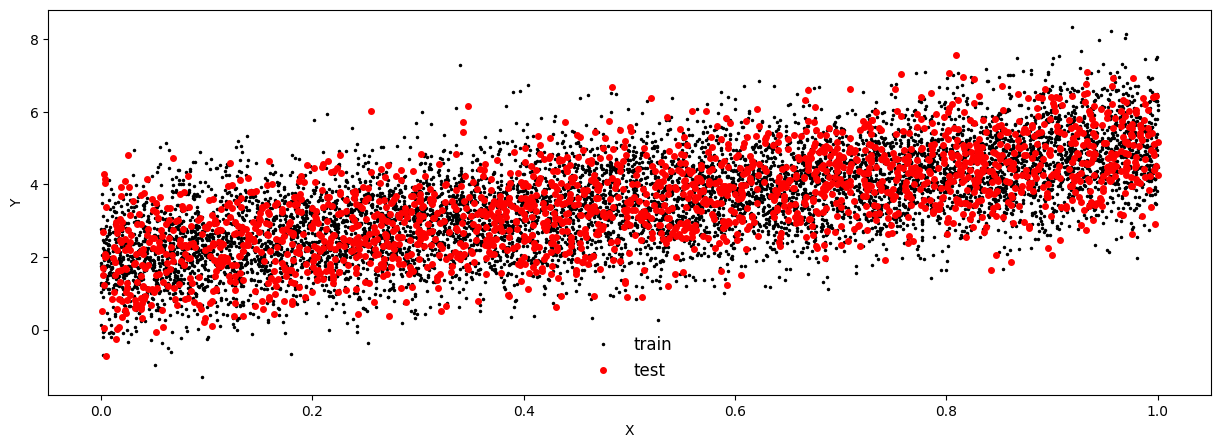

In [57]:
scatter_plot(X_train[:, 1], X_test [:, 1], y_train, y_test) 

In [58]:
def OLS(X, y):
    A = np.linalg.inv(np.dot(X.T, X))
    B = np.dot(X.T, y)

    return(np.dot(A.T, B))

w_ols = OLS(X_train, y_train)

In [59]:
# Train set
y_hat_train = MSE(np.dot(w_ols, X_train.T), y_train)

# Test set
y_hat_test = MSE(np.dot(w_ols, X_test.T), y_test)

print('MSE of the train: ', MSE(y_hat_train, y_train))
print('MSE of the test:  ', MSE(y_hat_test, y_test))

MSE of the train:  7.990615855673075
MSE of the test:   8.209801144215001


In [60]:
bias = w_ols - [w_0, w_1]
print("Bias of w_0: ", bias[0])
print("Bias of the w_1: ", bias[1])

Bias of w_0:  -0.05593780791469083
Bias of the w_1:  0.10285541777978313


In [61]:
mc_estimates = 10000   # Fix the number of Monte Carlo estimates that you want to run
M = np.zeros((mc_estimates, 2))  

In [66]:
for k in np.arange(mc_estimates):

    X, y = simu_data(sample_size, w_0, w_1)
    X = [np.ones(len(y)), X]
    X = np.array(X).T

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

    M[k, :] = OLS(X, y)

In [72]:
var = np.var(M, axis=0)
mean = np.mean(M, axis=0)

print('mean: ', mean, '¡ var: ', var)

mean:  [1.99958705 3.00117426] ¡ var:  [0.00407146 0.0122204 ]


In [74]:
np.linalg.inv(np.dot(X.T, X)).diagonal()

array([0.00376261, 0.01171386])

In [ ]:
    A = np.linalg.inv(np.dot(X.T, X))
    B = np.dot(X.T, y)

    return(np.dot(A.T, B))

In [89]:
def ridge(X, y, lambda_hp):
    A = np.dot(X.T, X)
    B = np.linalg.inv(A + lambda_hp * np.identity(A.shape[0]))
    return np.dot(B.T, np.dot(X.T, y))

In [90]:
ridge(X, y, 0.01)

array([2.07833307, 2.88274623])

In [91]:
lambda_hp = 10**3
w_ridge = ridge(X_train, y_train, lambda_hp)